In [21]:
import os

# Asegurar que exista la carpeta data (un nivel arriba de notebooks/)
os.makedirs("../data", exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de gráficas
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Cargar variables de entorno
load_dotenv()

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [7]:
# Obtener credenciales del entorno
DB_HOST = os.getenv('DB_HOST', 'localhost')
DB_PORT = os.getenv('DB_PORT', '5432')
DB_USER = os.getenv('DB_USER', 'postgres')
DB_PASSWORD = os.getenv('DB_PASSWORD')
DB_NAME = os.getenv('DB_NAME', 'weatherstack_etl')

# Construir URL de conexión
DATABASE_URL = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

# Crear engine
engine = create_engine(DATABASE_URL)

# Probar conexión
try:
    with engine.connect() as conn:
        print("✅ Conexión a PostgreSQL exitosa")
except Exception as e:
    print(f"❌ Error de conexión: {str(e)}")

✅ Conexión a PostgreSQL exitosa


In [10]:
# Consulta SQL corregida
query = """
SELECT 
    r.temperatura,
    r.humedad,
    r.velocidad_viento,
    c.nombre AS ciudad,
    r.fecha_extraccion
FROM registros_clima r
JOIN ciudades c ON r.ciudad_id = c.id
WHERE r.temperatura IS NOT NULL 
  AND r.humedad IS NOT NULL
ORDER BY r.fecha_extraccion DESC
"""

# Cargar en DataFrame
df = pd.read_sql(query, engine)

print(f"📊 Datos cargados: {len(df)} registros")
print("\n📄 Información del Dataset:")
print(df.info())

df.head(10)

📊 Datos cargados: 3010 registros

📄 Información del Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3010 entries, 0 to 3009
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   temperatura       3010 non-null   float64       
 1   humedad           3010 non-null   float64       
 2   velocidad_viento  3010 non-null   float64       
 3   ciudad            3010 non-null   object        
 4   fecha_extraccion  3010 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 117.7+ KB
None


,temperatura,humedad,velocidad_viento,ciudad,fecha_extraccion
0,27.0,79.0,30.0,Barranquilla,2026-04-03 22:12:07.922256
1,15.0,100.0,4.0,Medellin,2026-04-03 22:12:06.847884
2,14.0,88.0,4.0,Bogota,2026-04-03 22:12:04.506921
3,27.0,84.0,30.0,Cartagena,2026-04-03 22:05:29.675515
4,15.0,100.0,4.0,Medellin,2026-04-03 22:05:28.279993
5,14.0,88.0,4.0,Bogota,2026-04-03 22:05:26.102320
6,27.0,79.0,32.0,Barranquilla,2026-04-03 22:01:44.604934
7,19.0,88.0,4.0,Cali,2026-04-03 22:01:43.666749
8,15.0,100.0,4.0,Medellin,2026-04-03 22:01:42.512289
9,14.0,88.0,4.0,Bogota,2026-04-03 22:01:39.857313


📈 Estadísticas Descriptivas:
       temperatura      humedad  velocidad_viento
count  3010.000000  3010.000000       3010.000000
mean     24.075814    72.849535         13.932691
std       6.125854     6.518655          4.559899
min       8.100000    53.200000          1.100000
25%      20.500000    68.400000         10.800000
50%      25.700000    72.650000         13.500000
75%      28.900000    77.400000         17.200000
max      36.500000   100.000000         32.000000

🔗 Matriz de Correlación:
                  temperatura   humedad  velocidad_viento
temperatura          1.000000 -0.039594          0.253774
humedad             -0.039594  1.000000          0.368600
velocidad_viento     0.253774  0.368600          1.000000


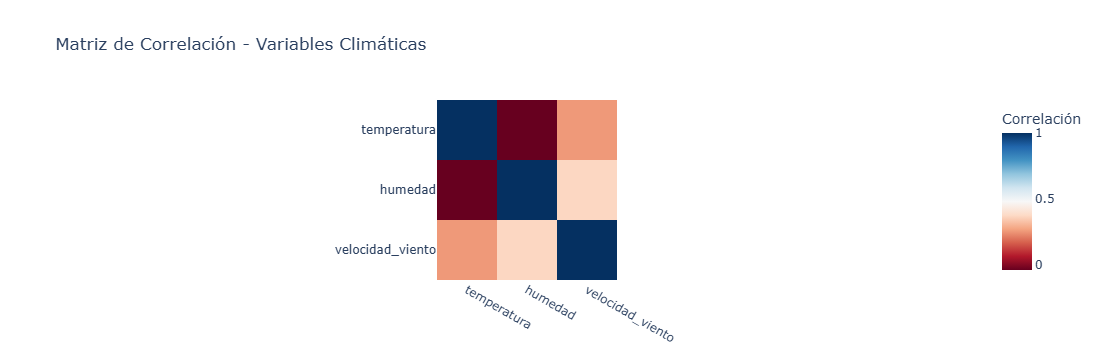

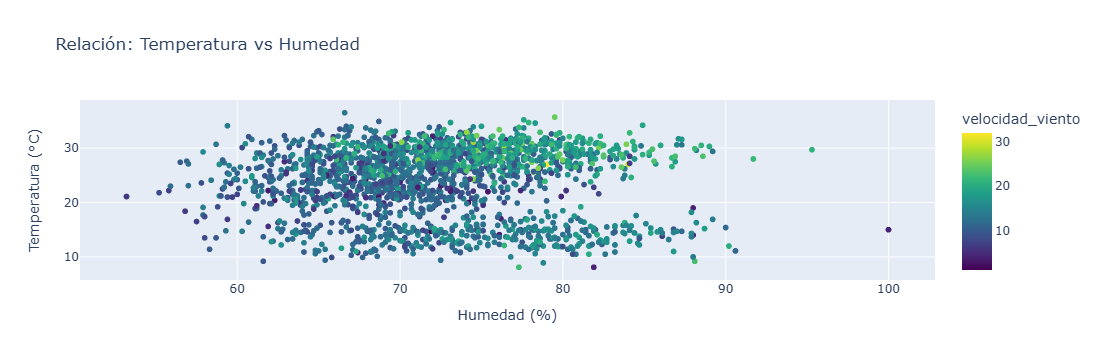

In [23]:
# Estadísticas descriptivas
print("📈 Estadísticas Descriptivas:")
print(df[['temperatura', 'humedad', 'velocidad_viento']].describe())

# Matriz de correlación
print("\n🔗 Matriz de Correlación:")
correlation = df[['temperatura', 'humedad', 'velocidad_viento']].corr()
print(correlation)

# Visualizar correlación
fig = px.imshow(
    correlation,
    labels=dict(color="Correlación"),
    title="Matriz de Correlación - Variables Climáticas",
    color_continuous_scale='RdBu'
)
fig.show()

# Scatter plot: Temperatura vs Humedad
fig = px.scatter(
    df, 
    x='humedad', 
    y='temperatura',
    title='Relación: Temperatura vs Humedad',
    labels={'humedad': 'Humedad (%)', 'temperatura': 'Temperatura (°C)'},
    color='velocidad_viento',
    color_continuous_scale='Viridis'
)
fig.show()

In [14]:
# Variables independientes (X): humedad y velocidad del viento
X = df[['humedad', 'velocidad_viento']].values

# Variable dependiente (y): temperatura
y = df['temperatura'].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Dividir datos: 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n📊 División de datos:")
print(f"  Entrenamiento: {len(X_train)} muestras ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Prueba: {len(X_test)} muestras ({len(X_test)/len(X)*100:.1f}%)")

X shape: (3010, 2)
y shape: (3010,)

📊 División de datos:
  Entrenamiento: 2408 muestras (80.0%)
  Prueba: 602 muestras (20.0%)


In [16]:
# Crear instancia del modelo
model = LinearRegression()

# Entrenar el modelo
model.fit(X_train, y_train)

print("✅ Modelo entrenado correctamente")

# Ver coeficientes
print(f"\n📐 Coeficientes del Modelo:")
print(f"  Intercepto (β₀): {model.intercept_:.4f}")
print(f"  Coeficiente Humedad (β₁): {model.coef_[0]:.4f}")
print(f"  Coeficiente Viento (β₂): {model.coef_[1]:.4f}")

# Interpretar coeficientes
print(f"\n💡 Interpretación:")
print(f"  Temperatura = {model.intercept_:.2f} + ({model.coef_[0]:.4f} × Humedad) + ({model.coef_[1]:.4f} × Viento)")
print(f"  Por cada 1% de humedad, la temp {'sube' if model.coef_[0] > 0 else 'baja'} {abs(model.coef_[0]):.4f}°C")
print(f"  Por cada 1 km/h de viento, la temp {'sube' if model.coef_[1] > 0 else 'baja'} {abs(model.coef_[1]):.4f}°C")

✅ Modelo entrenado correctamente

📐 Coeficientes del Modelo:
  Intercepto (β₀): 28.3327
  Coeficiente Humedad (β₁): -0.1412
  Coeficiente Viento (β₂): 0.4273

💡 Interpretación:
  Temperatura = 28.33 + (-0.1412 × Humedad) + (0.4273 × Viento)
  Por cada 1% de humedad, la temp baja 0.1412°C
  Por cada 1 km/h de viento, la temp sube 0.4273°C


In [17]:
# Predicciones en datos de entrenamiento
y_train_pred = model.predict(X_train)

# Predicciones en datos de prueba
y_test_pred = model.predict(X_test)

print("✅ Predicciones realizadas")
print(f"\nPrimeras 10 predicciones vs valores reales (conjunto de prueba):")
comparison = pd.DataFrame({
    'Humedad': X_test[:10, 0],
    'Viento': X_test[:10, 1],
    'Temp Real': y_test[:10],
    'Temp Predicha': y_test_pred[:10],
    'Error': y_test[:10] - y_test_pred[:10]
})
print(comparison)

✅ Predicciones realizadas

Primeras 10 predicciones vs valores reales (conjunto de prueba):
   Humedad  Viento  Temp Real  Temp Predicha      Error
0     89.0    19.9       30.3      24.269682   6.030318
1     70.1    11.7       24.3      23.434208   0.865792
2     78.3    13.6       15.6      23.088286  -7.488286
3     74.3     9.0       28.8      21.687306   7.112694
4     68.0    10.8       22.4      23.346126  -0.946126
5     72.1    11.7       24.4      23.151797   1.248203
6     80.9    15.7       12.0      23.618583 -11.618583
7     69.2    10.3       28.1      22.963005   5.136995
8     75.6    22.3       25.1      27.187467  -2.087467
9     81.0    19.4       29.4      25.185650   4.214350


In [18]:
# Calcular métricas en conjunto de entrenamiento
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Calcular métricas en conjunto de prueba
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("=" * 60)
print("📊 MÉTRICAS DEL MODELO DE REGRESIÓN LINEAL")
print("=" * 60)

print("\n🎯 CONJUNTO DE ENTRENAMIENTO:")
print(f"  MAE (Error Absoluto Medio):     {train_mae:.4f}°C")
print(f"  MSE (Error Cuadrático Medio):   {train_mse:.4f}")
print(f"  RMSE (Raíz del Error Cuadrático): {train_rmse:.4f}°C")
print(f"  R² (Coef. de Determinación):    {train_r2:.4f} ({train_r2*100:.2f}%)")

print("\n🧪 CONJUNTO DE PRUEBA:")
print(f"  MAE (Error Absoluto Medio):     {test_mae:.4f}°C")
print(f"  MSE (Error Cuadrático Medio):   {test_mse:.4f}")
print(f"  RMSE (Raíz del Error Cuadrático): {test_rmse:.4f}°C")
print(f"  R² (Coef. de Determinación):    {test_r2:.4f} ({test_r2*100:.2f}%)")

print("\n" + "=" * 60)

# Detectar overfitting
if abs(train_r2 - test_r2) > 0.1:
    print("⚠️  ALERTA: Posible overfitting (diferencia en R² > 0.1)")
else:
    print("✅ BUEN AJUSTE: El modelo generaliza bien")

📊 MÉTRICAS DEL MODELO DE REGRESIÓN LINEAL

🎯 CONJUNTO DE ENTRENAMIENTO:
  MAE (Error Absoluto Medio):     4.7528°C
  MSE (Error Cuadrático Medio):   34.2600
  RMSE (Raíz del Error Cuadrático): 5.8532°C
  R² (Coef. de Determinación):    0.0885 (8.85%)

🧪 CONJUNTO DE PRUEBA:
  MAE (Error Absoluto Medio):     4.8843°C
  MSE (Error Cuadrático Medio):   34.6470
  RMSE (Raíz del Error Cuadrático): 5.8862°C
  R² (Coef. de Determinación):    0.0662 (6.62%)

✅ BUEN AJUSTE: El modelo generaliza bien


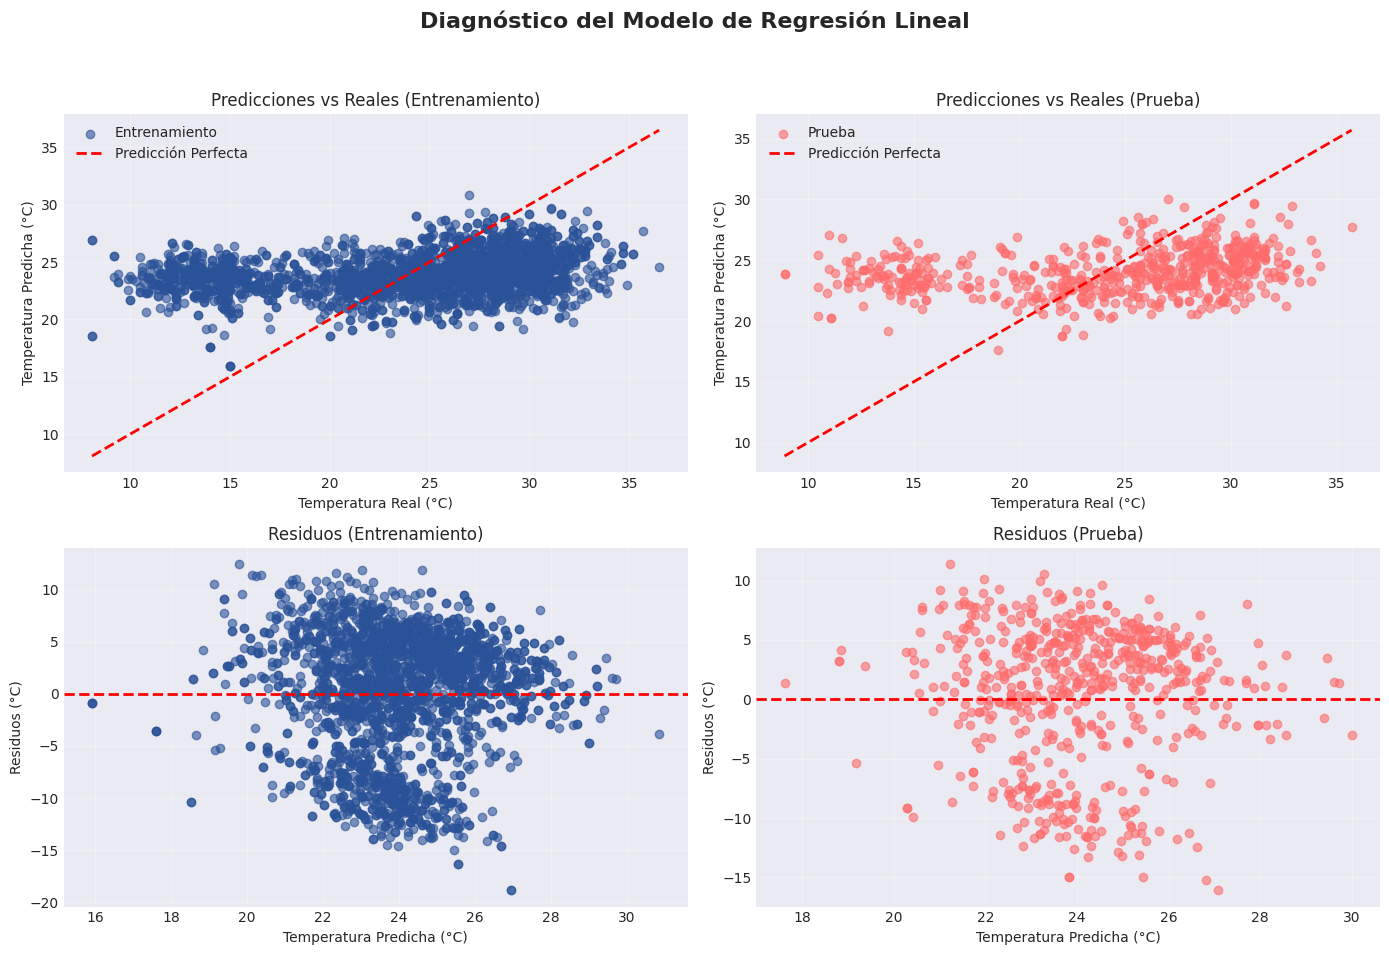

✅ Gráficas guardadas en data/diagnosticos_modelo.png


In [20]:
# Crear figura con subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Diagnóstico del Modelo de Regresión Lineal', fontsize=16, fontweight='bold')

# Gráfica 1: Valores Predichos vs Reales (Entrenamiento)
axes[0, 0].scatter(y_train, y_train_pred, alpha=0.6, color='#2a5298', label='Entrenamiento')
axes[0, 0].plot(
    [y_train.min(), y_train.max()],
    [y_train.min(), y_train.max()],
    'r--', lw=2, label='Predicción Perfecta'
)
axes[0, 0].set_xlabel('Temperatura Real (°C)')
axes[0, 0].set_ylabel('Temperatura Predicha (°C)')
axes[0, 0].set_title('Predicciones vs Reales (Entrenamiento)')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Gráfica 2: Valores Predichos vs Reales (Prueba)
axes[0, 1].scatter(y_test, y_test_pred, alpha=0.6, color='#ff6b6b', label='Prueba')
axes[0, 1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', lw=2, label='Predicción Perfecta'
)
axes[0, 1].set_xlabel('Temperatura Real (°C)')
axes[0, 1].set_ylabel('Temperatura Predicha (°C)')
axes[0, 1].set_title('Predicciones vs Reales (Prueba)')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Gráfica 3: Residuos (Entrenamiento)
residuals_train = y_train - y_train_pred
axes[1, 0].scatter(y_train_pred, residuals_train, alpha=0.6, color='#2a5298')
axes[1, 0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Temperatura Predicha (°C)')
axes[1, 0].set_ylabel('Residuos (°C)')
axes[1, 0].set_title('Residuos (Entrenamiento)')
axes[1, 0].grid(alpha=0.3)

# Gráfica 4: Residuos (Prueba)
residuals_test = y_test - y_test_pred
axes[1, 1].scatter(y_test_pred, residuals_test, alpha=0.6, color='#ff6b6b')
axes[1, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Temperatura Predicha (°C)')
axes[1, 1].set_ylabel('Residuos (°C)')
axes[1, 1].set_title('Residuos (Prueba)')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# ✅ Guardar en la carpeta data
plt.savefig("../data/diagnosticos_modelo.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráficas guardadas en data/diagnosticos_modelo.png")